In [1]:
import sys
sys.path.insert(0, '/myhome/iris')

from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import re

from src.models.cnet import CNet
from src.data_pipeline.dataset import ModularCellDataModule
from src.evaluation.evaluator import Evaluator, EvaluationConfig
from src.evaluation.utils import load_model_from_checkpoint, load_ckpt_artifacts, get_device

## Configuration

Set the experiment ID you want to evaluate. The script will find the newest model trained with this holdout.

In [2]:
# Paths
LIGHTNING_LOGS_DIR = Path("/myhome/iris/lightning_logs")

# Device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cpu


/opt/conda/envs/iris_env/lib/python3.10/site-packages/torch/cuda/__init__.py:827: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


## Find the newest holdout model checkpoint

In [3]:
def find_exp_ids(logs_dir: Path) -> list:
    """Find all unique experiment IDs in the logs directory."""
    pattern = "holdout_*_*"
    folders = list(logs_dir.glob(pattern))
    exp_ids = set()
    for folder in folders:
        match = re.match(r'holdout_([^_]+)_.*', folder.name)
        if match:
            exp_ids.add(match.group(1))
    return sorted(exp_ids)

def find_holdout_folders(logs_dir: Path, exp_id: str) -> list:
    """Find all folders matching holdout_{exp_id}_* pattern."""
    pattern = f"holdout_{exp_id}_*"
    folders = list(logs_dir.glob(pattern))
    return sorted(folders, key=lambda x: x.name, reverse=True)  # Newest first (by name/timestamp)


def get_best_checkpoint(holdout_folder: Path) -> Path:
    """Find the best checkpoint in the holdout folder based on val_loss."""
    # Navigate to checkpoints directory
    # Structure: holdout_folder/cell-cycle-loeo/{wandb_id}/checkpoints/
    checkpoint_dirs = list(holdout_folder.rglob("checkpoints"))
    
    if not checkpoint_dirs:
        raise FileNotFoundError(f"No checkpoints directory found in {holdout_folder}")
    
    # Get all checkpoint files
    all_ckpts = []
    for ckpt_dir in checkpoint_dirs:
        all_ckpts.extend(list(ckpt_dir.glob("*.ckpt")))
    
    if not all_ckpts:
        raise FileNotFoundError(f"No checkpoint files found in {holdout_folder}")
    
    # Parse val_loss from filename and find best
    best_ckpt = None
    best_val_loss = float('inf')
    
    for ckpt in all_ckpts:
        # Pattern: epoch{N}-val_loss{X.XXXX}.ckpt
        match = re.search(r'val_loss([0-9.]+)', ckpt.name)
        if match:
            val_loss = float(match.group(1)[:-1]) 
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_ckpt = ckpt
    
    if best_ckpt is None:
        # Fallback: just take the first checkpoint
        best_ckpt = all_ckpts[0]
    
    return best_ckpt


# Find holdout folders
exp_ids_holdout_folders = {}
for exp_id in find_exp_ids(LIGHTNING_LOGS_DIR):
    holdout_folders = find_holdout_folders(LIGHTNING_LOGS_DIR, exp_id)
    exp_ids_holdout_folders[exp_id] = holdout_folders
    print(f"Found {len(holdout_folders)} holdout folders for exp_id '{exp_id}':")
    for folder in holdout_folders:
        print(f"  - {folder.name}")

Found 14 holdout folders for exp_id 'CL023':
  - holdout_CL023_20251217-120956
  - holdout_CL023_20251216-211820
  - holdout_CL023_20251216-175111
  - holdout_CL023_20251212-171420
  - holdout_CL023_20251212-163912
  - holdout_CL023_20251212-163723
  - holdout_CL023_20251210-074934
  - holdout_CL023_20251210-074426
  - holdout_CL023_20251210-074339
  - holdout_CL023_20251209-204541
  - holdout_CL023_20251209-201513
  - holdout_CL023_20251209-201426
  - holdout_CL023_20251209-201340
  - holdout_CL023_20251209-200515
Found 3 holdout folders for exp_id 'JP241':
  - holdout_JP241_20251217-120832
  - holdout_JP241_20251216-170120
  - holdout_JP241_20251212-171514
Found 4 holdout folders for exp_id 'JP242':
  - holdout_JP242_20251217-121120
  - holdout_JP242_20251216-203637
  - holdout_JP242_20251216-170221
  - holdout_JP242_20251212-190441
Found 5 holdout folders for exp_id 'JP277':
  - holdout_JP277_20251217-121120
  - holdout_JP277_20251216-205146
  - holdout_JP277_20251216-170431
  - hol

In [4]:
# Get the newest holdout folder (first in sorted list)
if not holdout_folders:
    raise ValueError(f"No holdout folders found for exp_id '{HOLDOUT_EXP_ID}'")

newest_holdout_folder = holdout_folders[0]
print(f"\nUsing newest holdout folder: {newest_holdout_folder.name}")

# Find the best checkpoint
exp_id_best_ckpt_path = {}
for exp_id, folders in exp_ids_holdout_folders.items():
    if folders:
        newest_folder = folders[0]
        best_ckpt_path = get_best_checkpoint(newest_folder)
        exp_id_best_ckpt_path[exp_id] = best_ckpt_path
        print(f"Best checkpoint for exp_id '{exp_id}': {best_ckpt_path}")
        print(f"Checkpoint subfolder: {best_ckpt_path.parent.relative_to(newest_folder)}")


Using newest holdout folder: holdout_NG049_20251217-202005
Best checkpoint for exp_id 'CL023': /myhome/iris/lightning_logs/holdout_CL023_20251217-120956/cell-cycle-loeo/g69jj4i1/checkpoints/epoch102-val_loss0.0229.ckpt
Checkpoint subfolder: cell-cycle-loeo/g69jj4i1/checkpoints
Best checkpoint for exp_id 'JP241': /myhome/iris/lightning_logs/holdout_JP241_20251217-120832/cell-cycle-loeo/ivvpbgw8/checkpoints/epoch82-val_loss0.0186.ckpt
Checkpoint subfolder: cell-cycle-loeo/ivvpbgw8/checkpoints
Best checkpoint for exp_id 'JP242': /myhome/iris/lightning_logs/holdout_JP242_20251217-121120/cell-cycle-loeo/paxwlkg9/checkpoints/epoch93-val_loss0.0218.ckpt
Checkpoint subfolder: cell-cycle-loeo/paxwlkg9/checkpoints
Best checkpoint for exp_id 'JP277': /myhome/iris/lightning_logs/holdout_JP277_20251217-121120/cell-cycle-loeo/lvuz7bgp/checkpoints/epoch98-val_loss0.0217.ckpt
Checkpoint subfolder: cell-cycle-loeo/lvuz7bgp/checkpoints
Best checkpoint for exp_id 'NG015': /myhome/iris/lightning_logs/hol

## Load model and data

In [5]:
# Load model, dataloader, and projector from checkpoint
exp_id_artifacts = {}
for exp_id, best_ckpt_path in exp_id_best_ckpt_path.items():
    model, dataloader, projector = load_ckpt_artifacts(
        str(best_ckpt_path), 
        split="test",  # Use test split which contains the holdout exp_id
        device=DEVICE
    )
    exp_id_artifacts[exp_id] = (model, dataloader, projector)
    print(f"\nModel loaded successfully")
    print(f"Model type: {type(model).__name__}")
    print(f"Test dataloader samples: {len(dataloader.dataset)}")

Loading checkpoint from: /myhome/iris/lightning_logs/holdout_CL023_20251217-120956/cell-cycle-loeo/g69jj4i1/checkpoints/epoch102-val_loss0.0229.ckpt

Setting up ModularCellDataModule

Creating feature transform pipeline
   - Using [{'class_path': 'sklearn.preprocessing.StandardScaler', 'init_args': {}}] transforms

Creating image transform pipeline
   - Using [] transforms

Creating data source from: /myhome/iris/data/fucci_3t3_221124_filtered_noNG030JP208_with_nuclei_seg.h5
   ✓ Found 22,677 total cells

Applying quality filters:
   - Plane count: 3
   - Max objects: 1
   - Min segmentation pixels: 10
   - Max nuclei outside ratio: 0.2
✓ Loaded filter results from cache: /myhome/iris/data/fucci_3t3_221124_filtered_noNG030JP208_with_nuclei_seg_filtered_23c07912.json

FILTERING STATISTICS
Total cells:                22,677
Valid cells:                16,759
Invalid cells:              5,918

Rejection reasons:
  - nuclei_too_large              : 2,540
  - exp_id_excluded               :

## Run inference on holdout data

In [6]:
from tqdm import tqdm
def run_inference(model, dataloader):
    """Run inference on the dataloader using the model."""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Running inference"):
            # Handle different batch formats
            if isinstance(batch, (tuple, list)):
                if len(batch[0]) == 2:
                    (images, features), labels = batch
                    images = images.to(DEVICE)
                    features = features.to(DEVICE)
                    preds = model(images, features)
                else:
                    images, labels = batch
                    images = images.to(DEVICE)
                    preds = model(images)
            else:
                images = batch['image'].to(DEVICE)
                labels = batch['label']
                preds = model(images)
            
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.numpy())

    # Concatenate results
    y_pred = np.concatenate(all_preds, axis=0)
    y_true = np.concatenate(all_labels, axis=0)
    return y_pred, y_true

exp_id_evaluation_preds = {}
for exp_id, (model, dataloader, projector) in tqdm(exp_id_artifacts.items(), desc="Evaluating experiments"):
    y_pred, y_true = run_inference(model, dataloader)
    exp_id_evaluation_preds[exp_id] = (y_pred, y_true)
    print(f"\nPredictions shape: {y_pred.shape}")
    print(f"Labels shape: {y_true.shape}")
    

Evaluating experiments:   8%|▊         | 1/12 [01:35<17:27, 95.21s/it]


Predictions shape: (1833, 1)
Labels shape: (1833, 1)


Evaluating experiments:  17%|█▋        | 2/12 [02:50<13:55, 83.51s/it]


Predictions shape: (1292, 1)
Labels shape: (1292, 1)


Evaluating experiments:  25%|██▌       | 3/12 [06:50<23:13, 154.81s/it]

...


Predictions shape: (1058, 1)
Labels shape: (1058, 1)


Evaluating experiments:  92%|█████████▏| 11/12 [14:27<00:54, 54.46s/it]


Predictions shape: (717, 1)
Labels shape: (717, 1)


Evaluating experiments: 100%|██████████| 12/12 [15:52<00:00, 79.36s/it]


Predictions shape: (1442, 1)
Labels shape: (1442, 1)


## Evaluate model performance


Evaluating exp_id: CL023

EVALUATION RESULTS - Holdout exp_id: CL023

Evaluating exp_id: JP241

EVALUATION RESULTS - Holdout exp_id: CL023

Evaluating exp_id: JP242

EVALUATION RESULTS - Holdout exp_id: CL023

Evaluating exp_id: JP277

EVALUATION RESULTS - Holdout exp_id: CL023

Evaluating exp_id: NG015

EVALUATION RESULTS - Holdout exp_id: CL023

Evaluating exp_id: NG016

EVALUATION RESULTS - Holdout exp_id: CL023

Evaluating exp_id: NG018

EVALUATION RESULTS - Holdout exp_id: CL023

Evaluating exp_id: NG019

EVALUATION RESULTS - Holdout exp_id: CL023

Evaluating exp_id: NG026

EVALUATION RESULTS - Holdout exp_id: CL023

Evaluating exp_id: NG028

EVALUATION RESULTS - Holdout exp_id: CL023

Evaluating exp_id: NG029


/myhome/iris/src/evaluation/plots.py:121: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=self.config.figsize, dpi=self.config.dpi)



EVALUATION RESULTS - Holdout exp_id: CL023

Evaluating exp_id: NG049

EVALUATION RESULTS - Holdout exp_id: CL023

SUMMARY OF EVALUATION RESULTS FOR ALL EXP_IDS

Results for exp_id: CL023
----------------------------------------
Metrics:
  test/geodesic_mae: 0.12037483602762222
  test/geodesic_mse: 0.02260798215866089
  test/geodesic_rmse: 0.15035950970477688
  test/geodesic_r2: 0.48590409755706787

Results for exp_id: JP241
----------------------------------------
Metrics:
  test/geodesic_mae: 0.13419198989868164
  test/geodesic_mse: 0.027594050392508507
  test/geodesic_rmse: 0.1661145700789323
  test/geodesic_r2: 0.5305807590484619

Results for exp_id: JP242
----------------------------------------
Metrics:
  test/geodesic_mae: 0.11508883535861969
  test/geodesic_mse: 0.023533249273896217
  test/geodesic_rmse: 0.15340550600906155
  test/geodesic_r2: 0.5906561613082886

Results for exp_id: JP277
----------------------------------------
Metrics:
  test/geodesic_mae: 0.11545508354902267

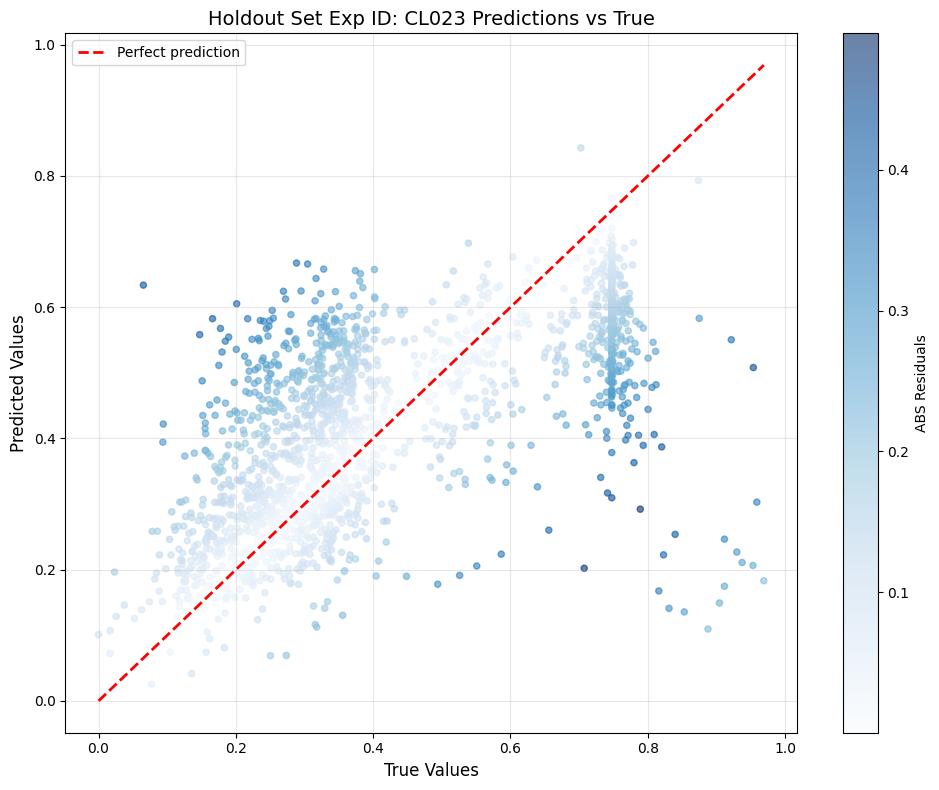

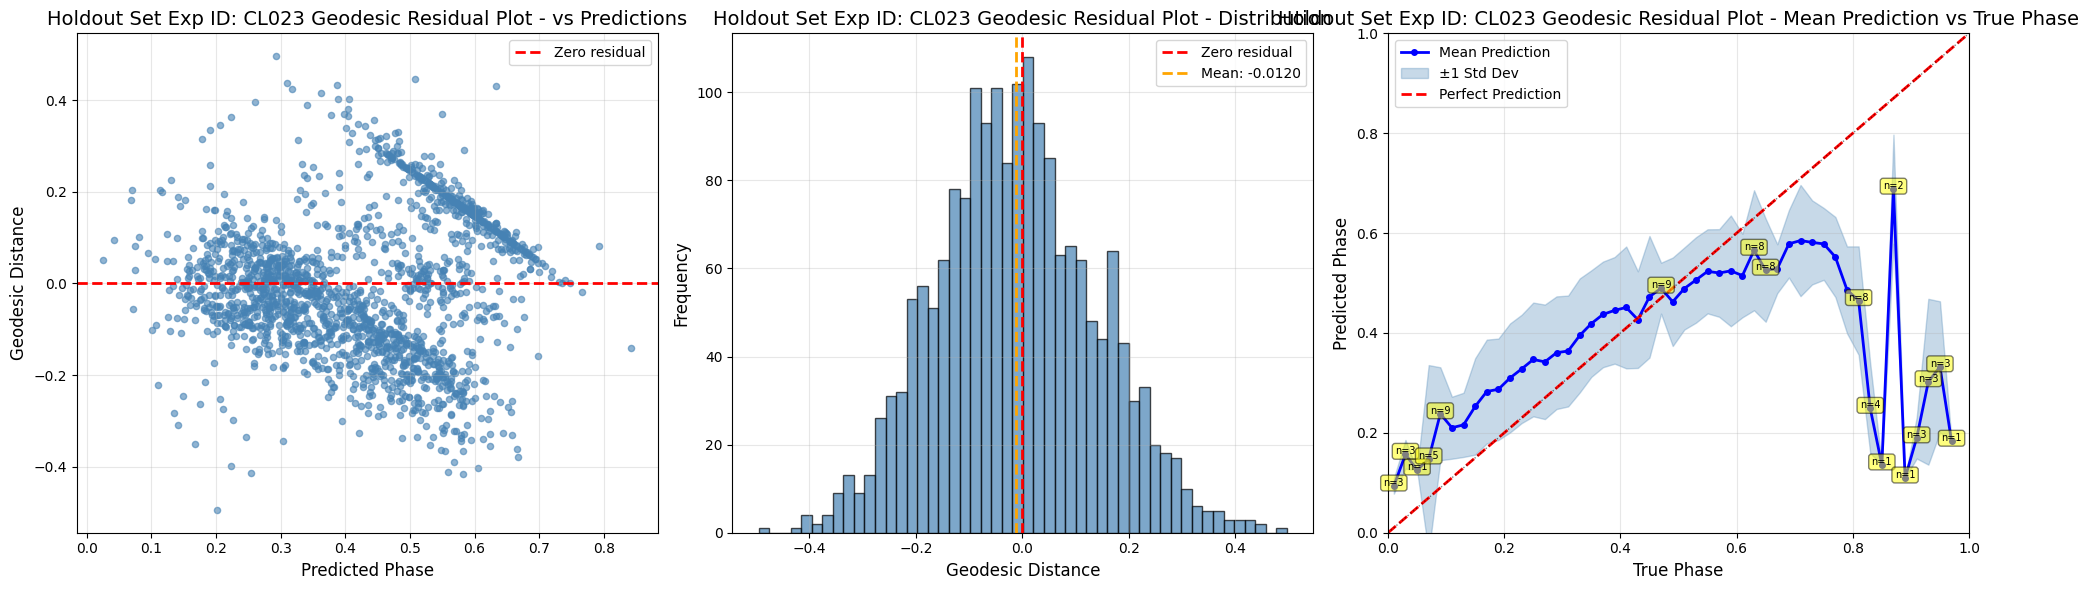

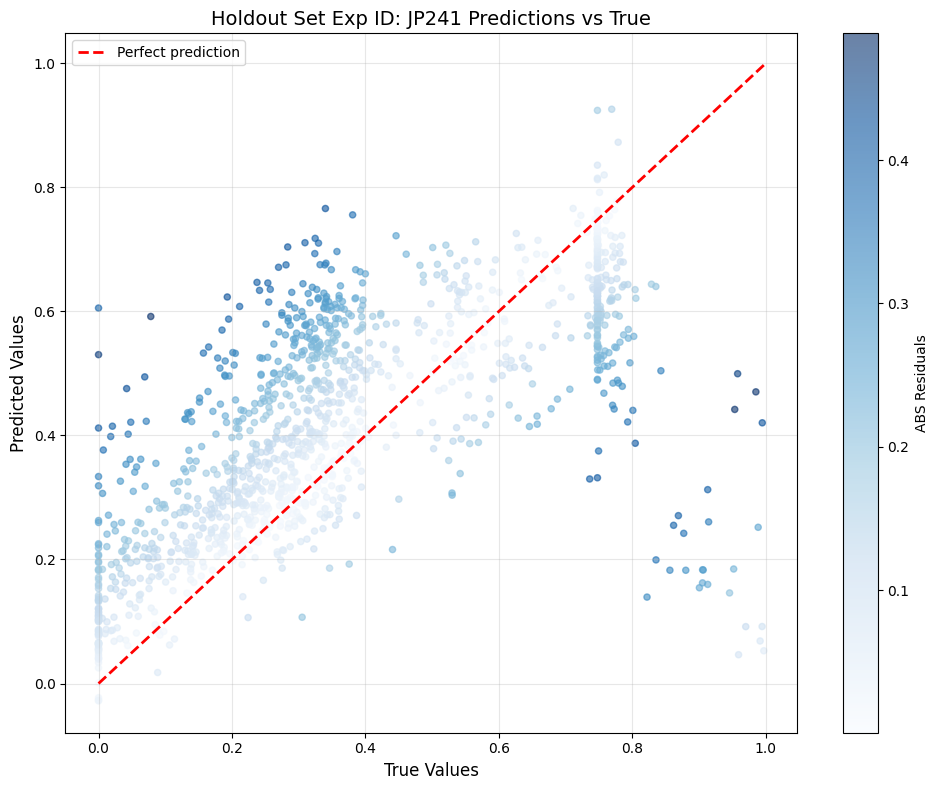

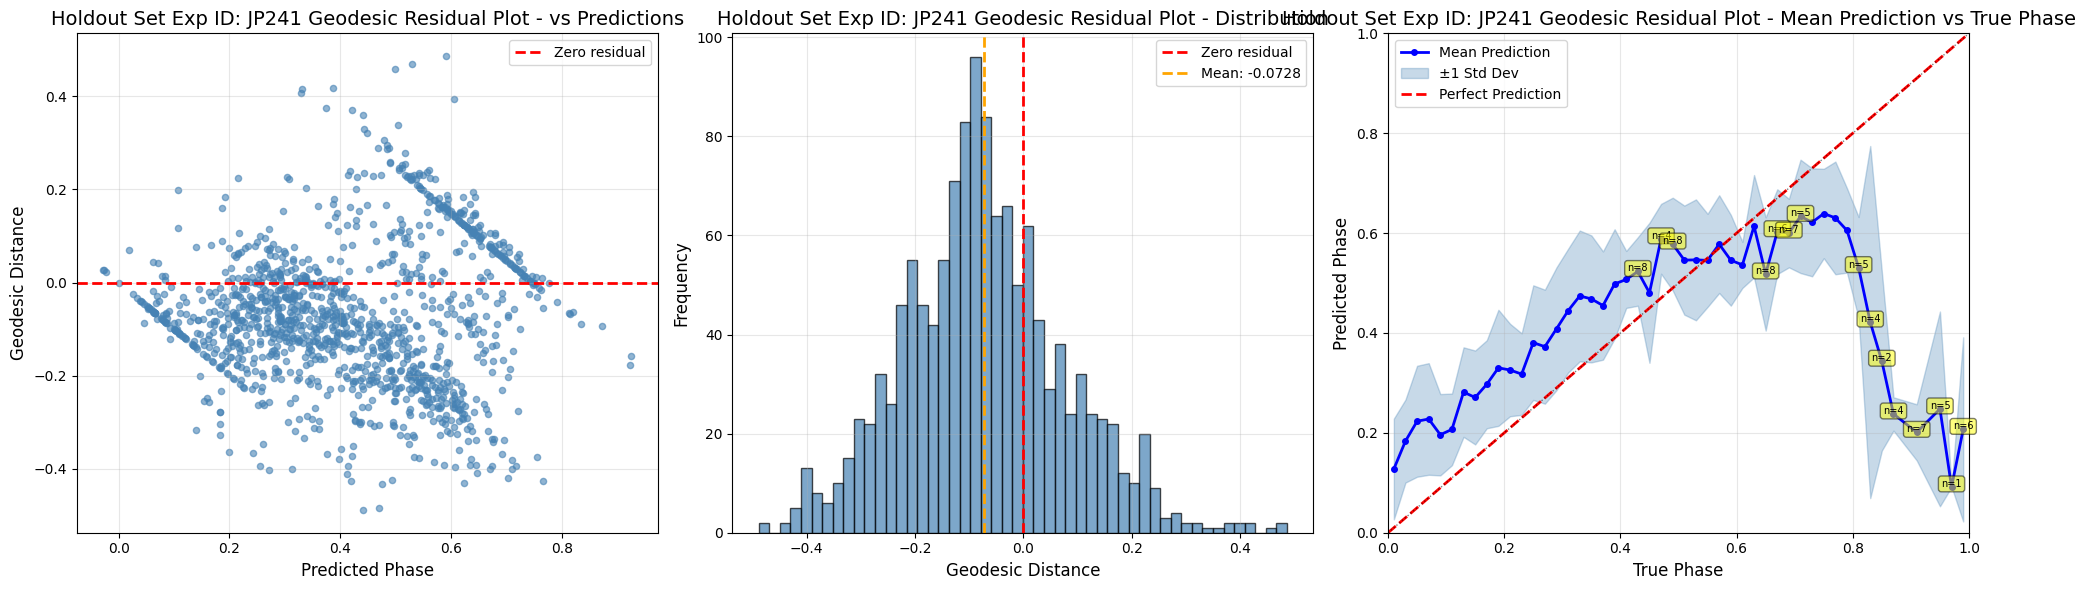

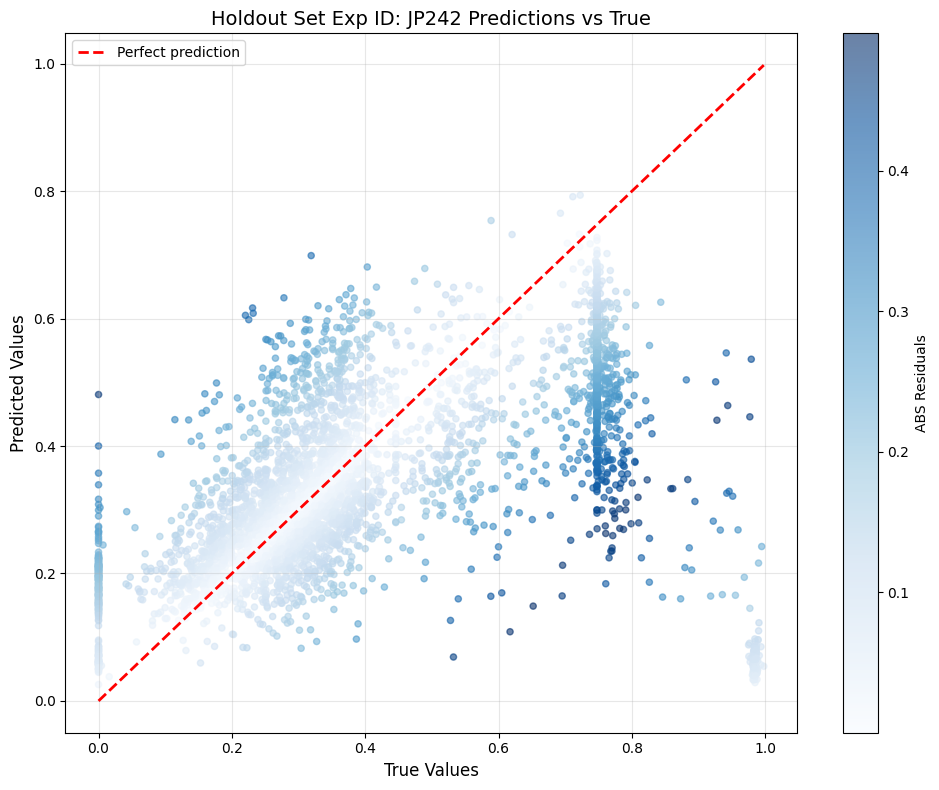

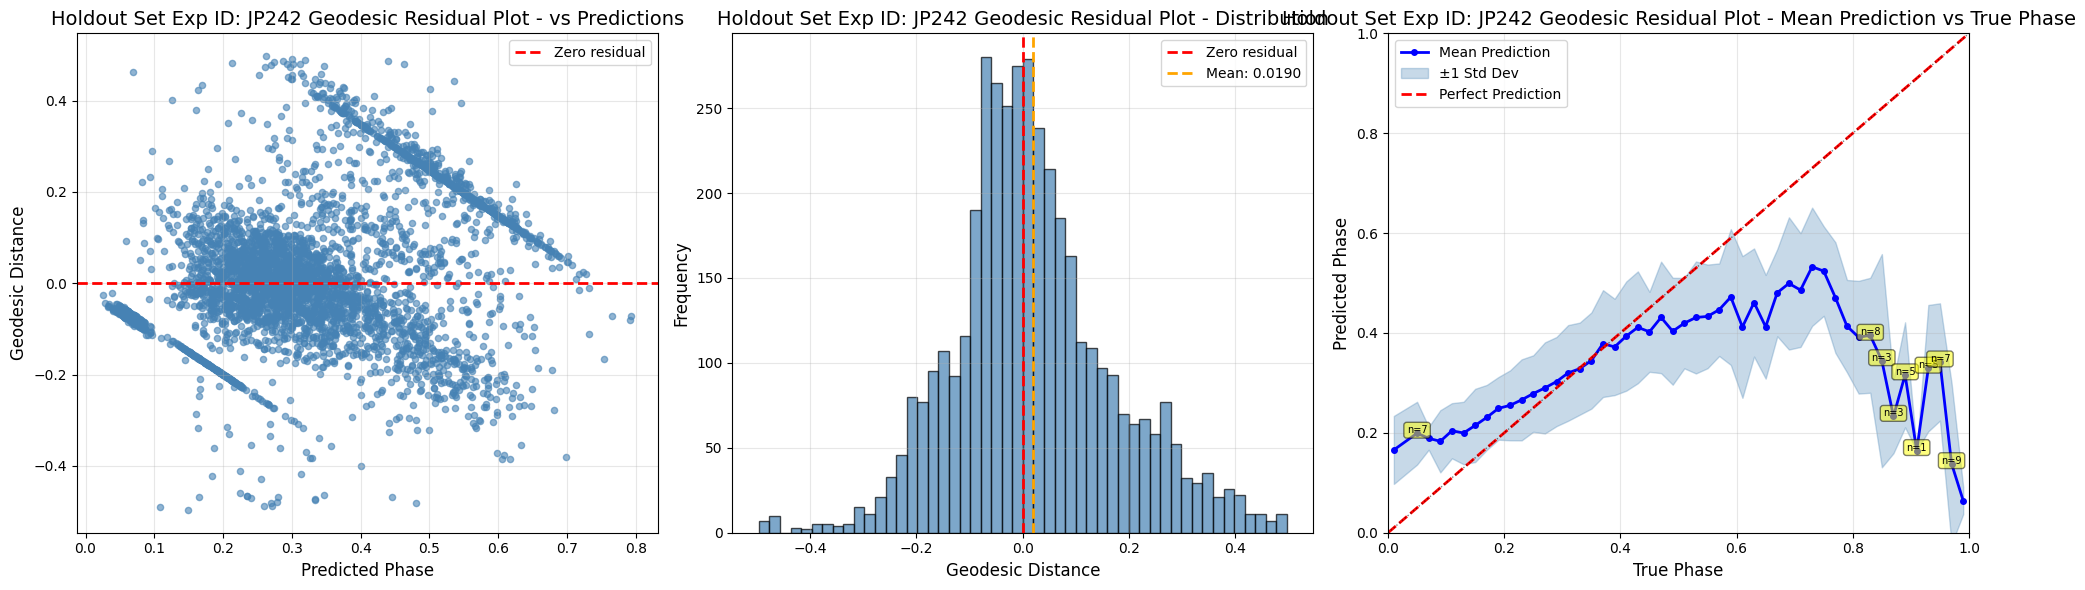

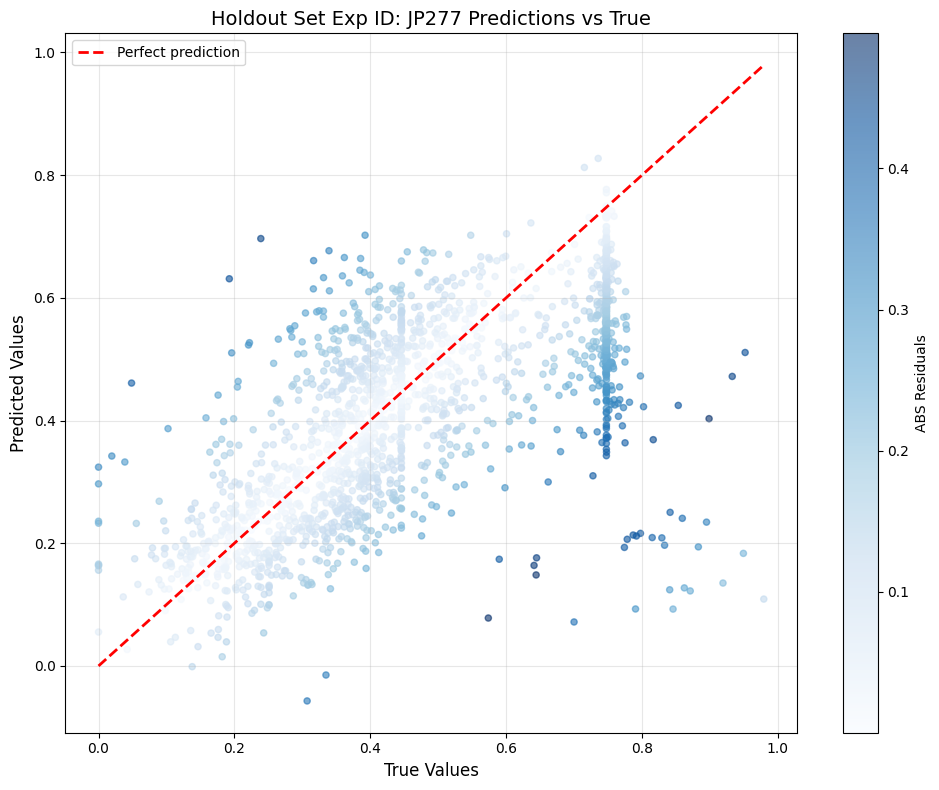

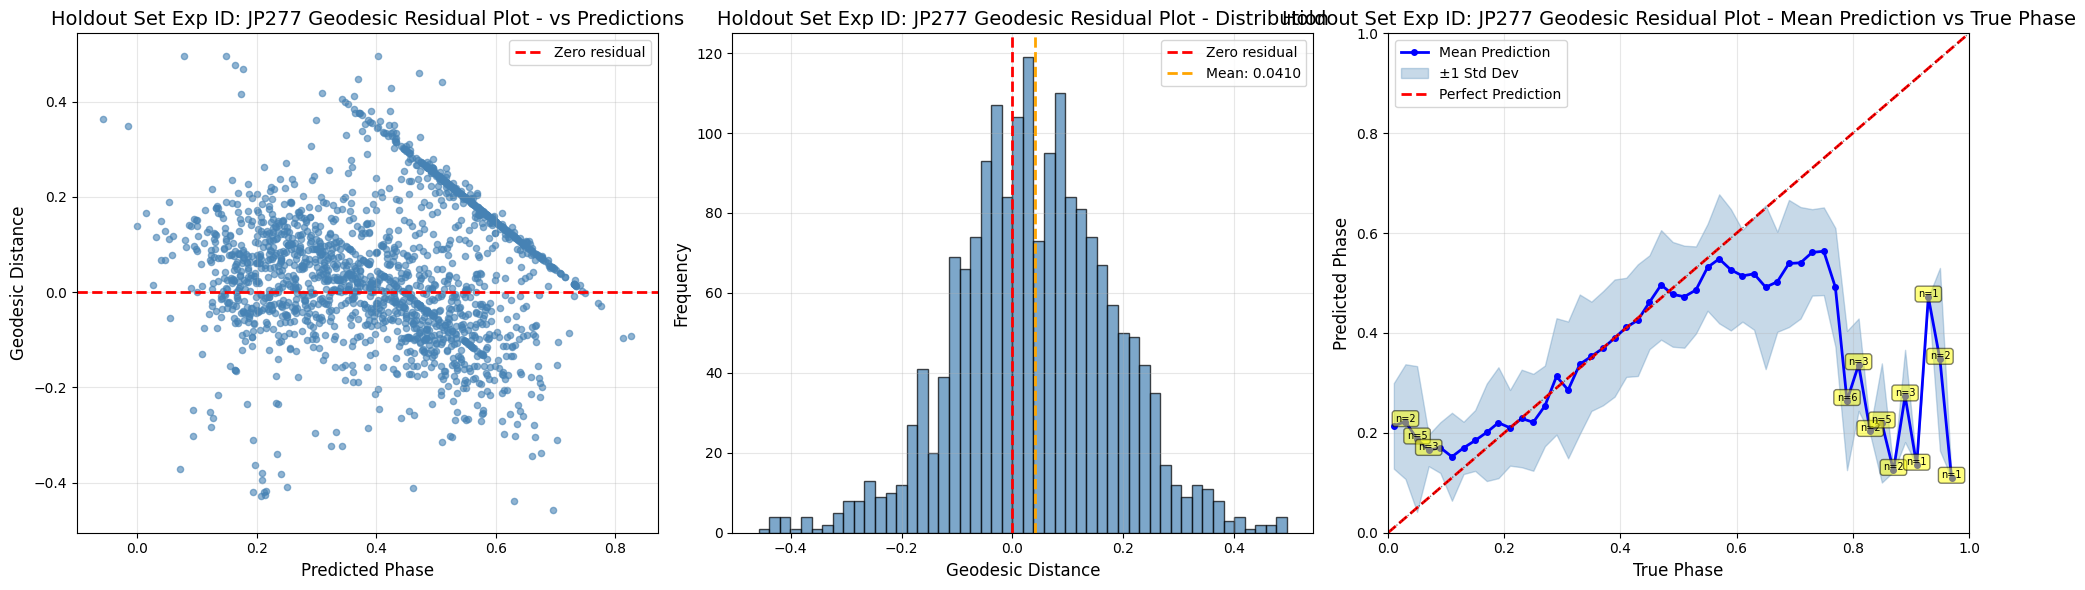

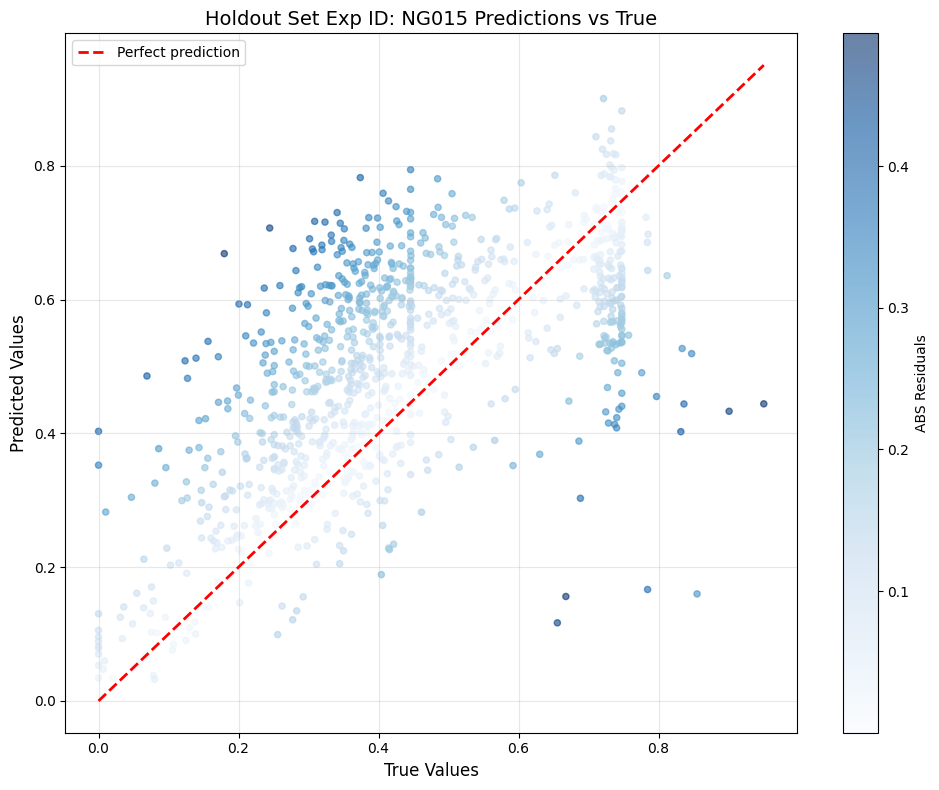

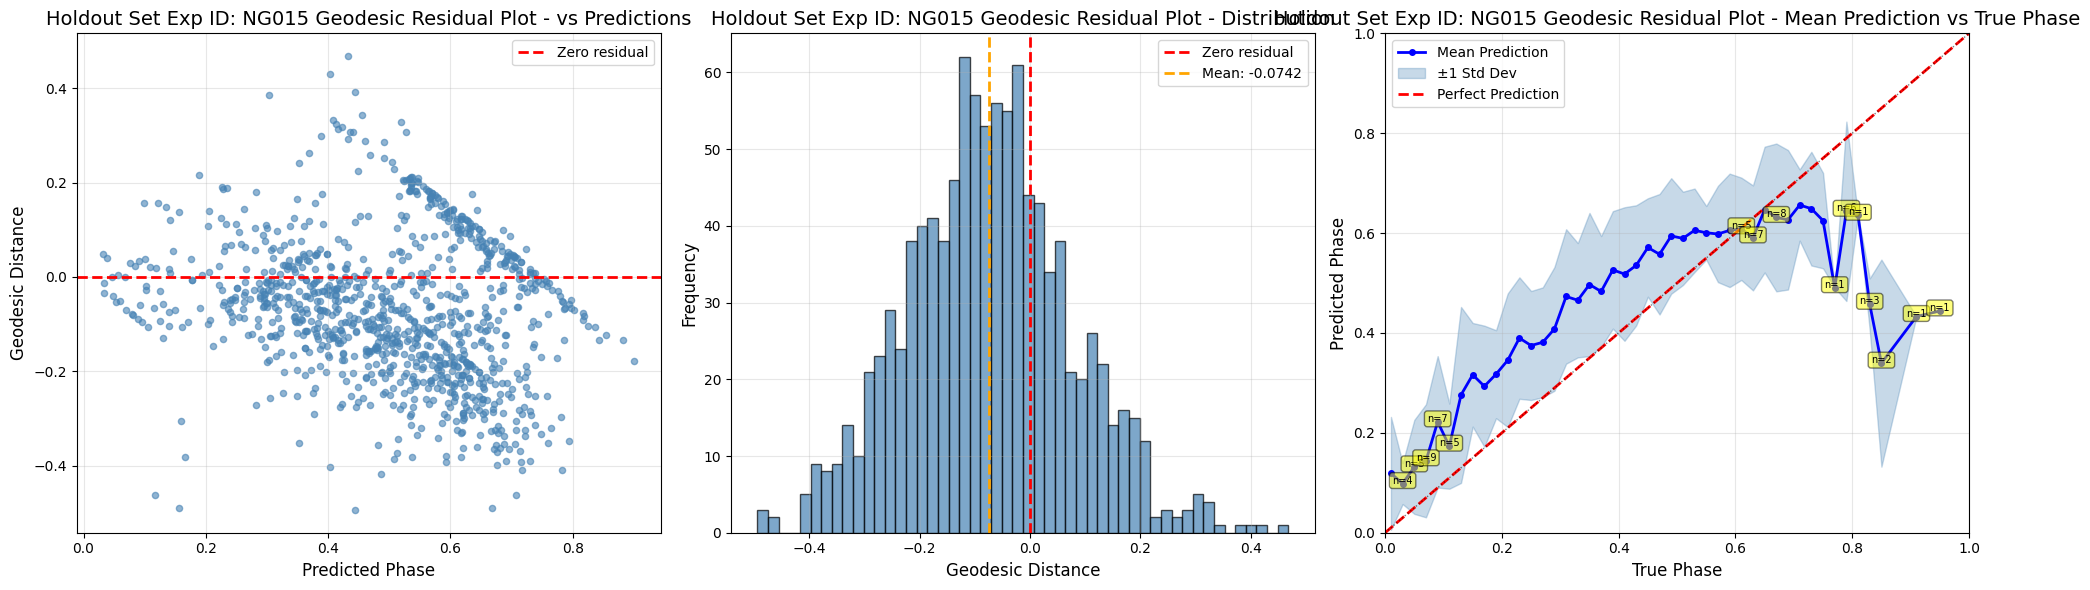

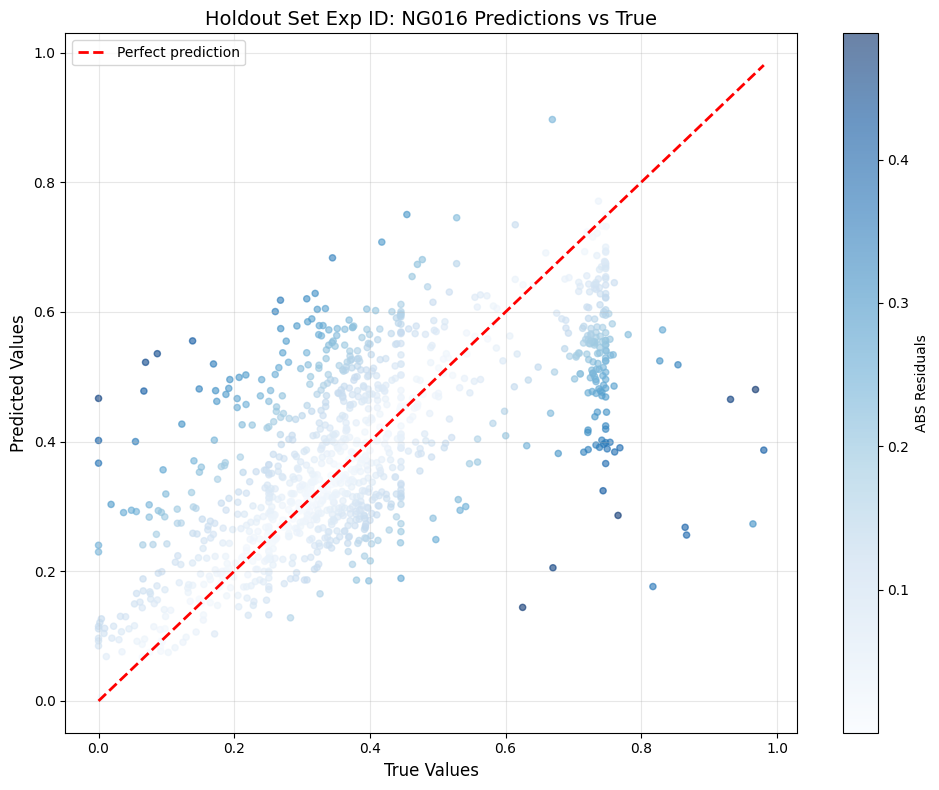

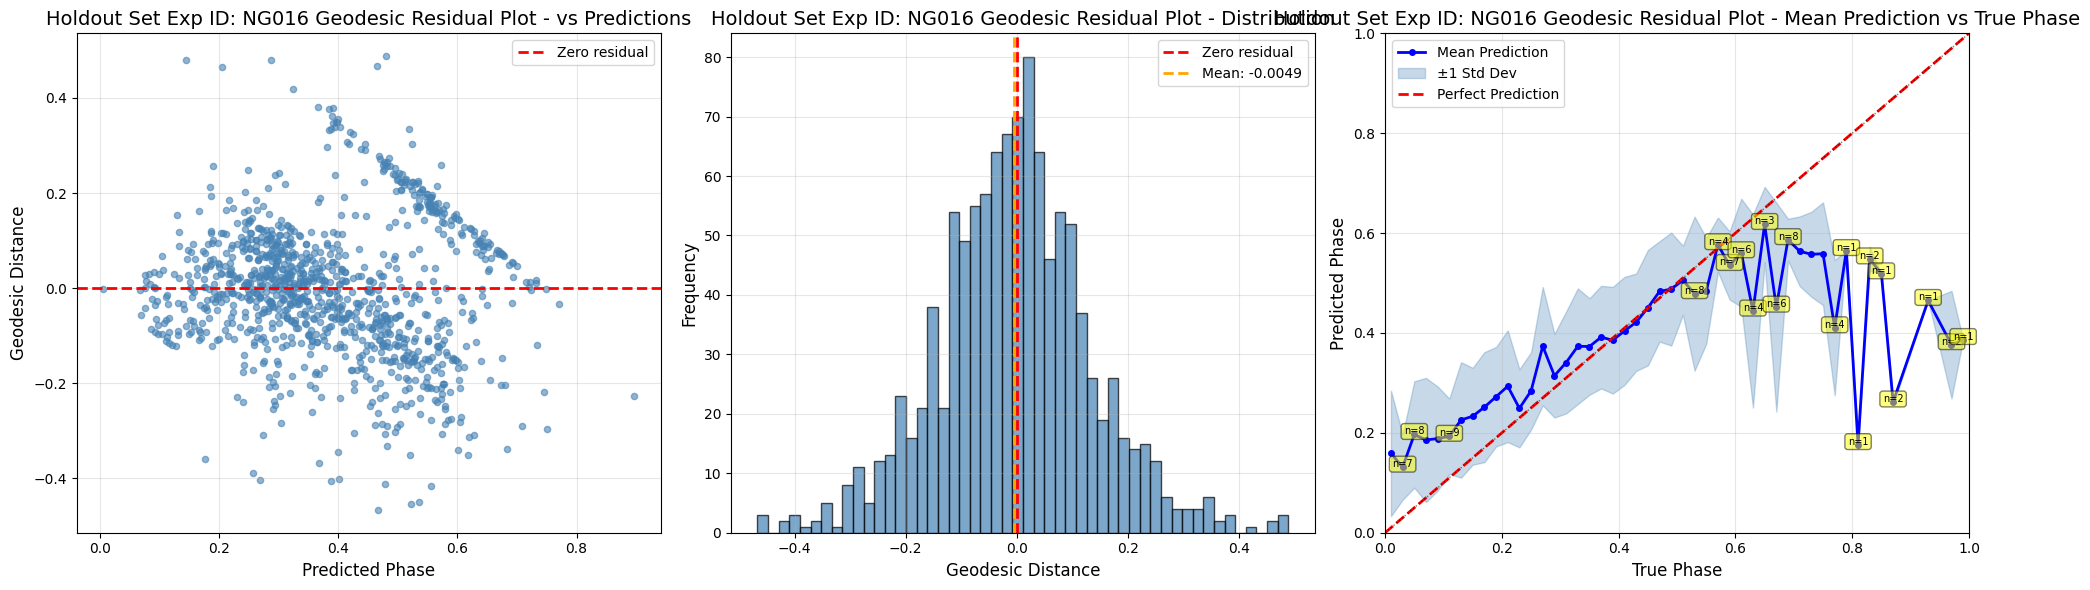

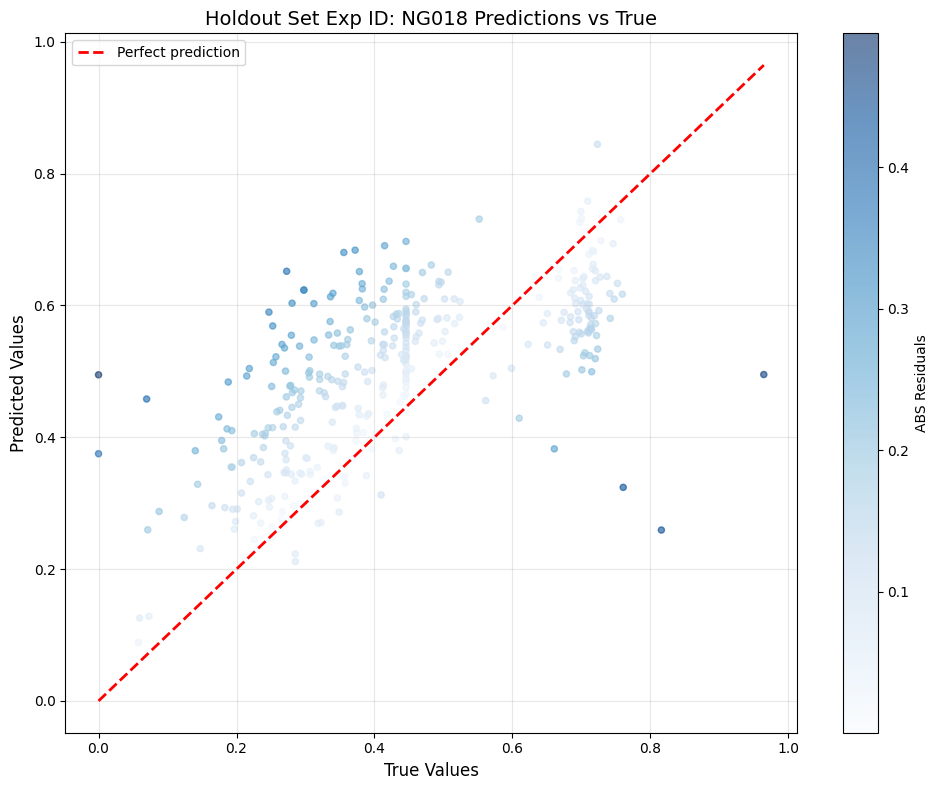

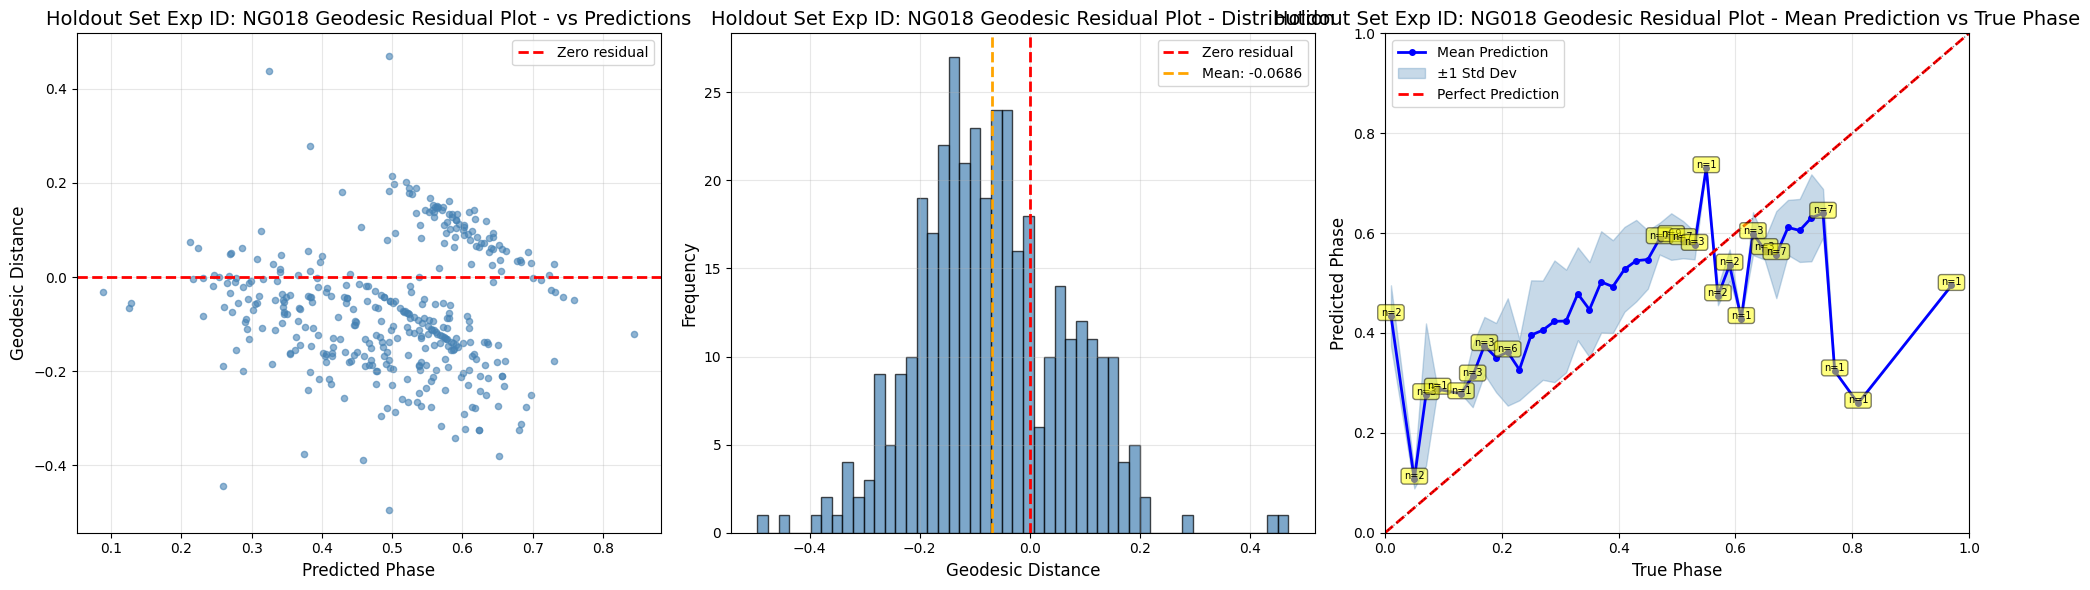

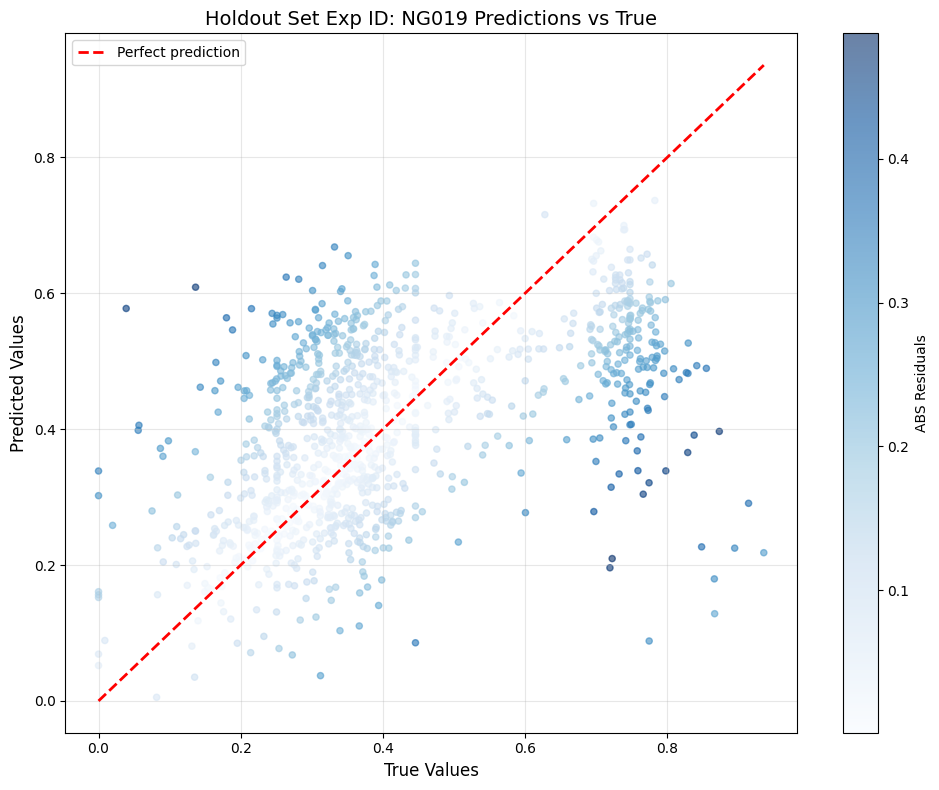

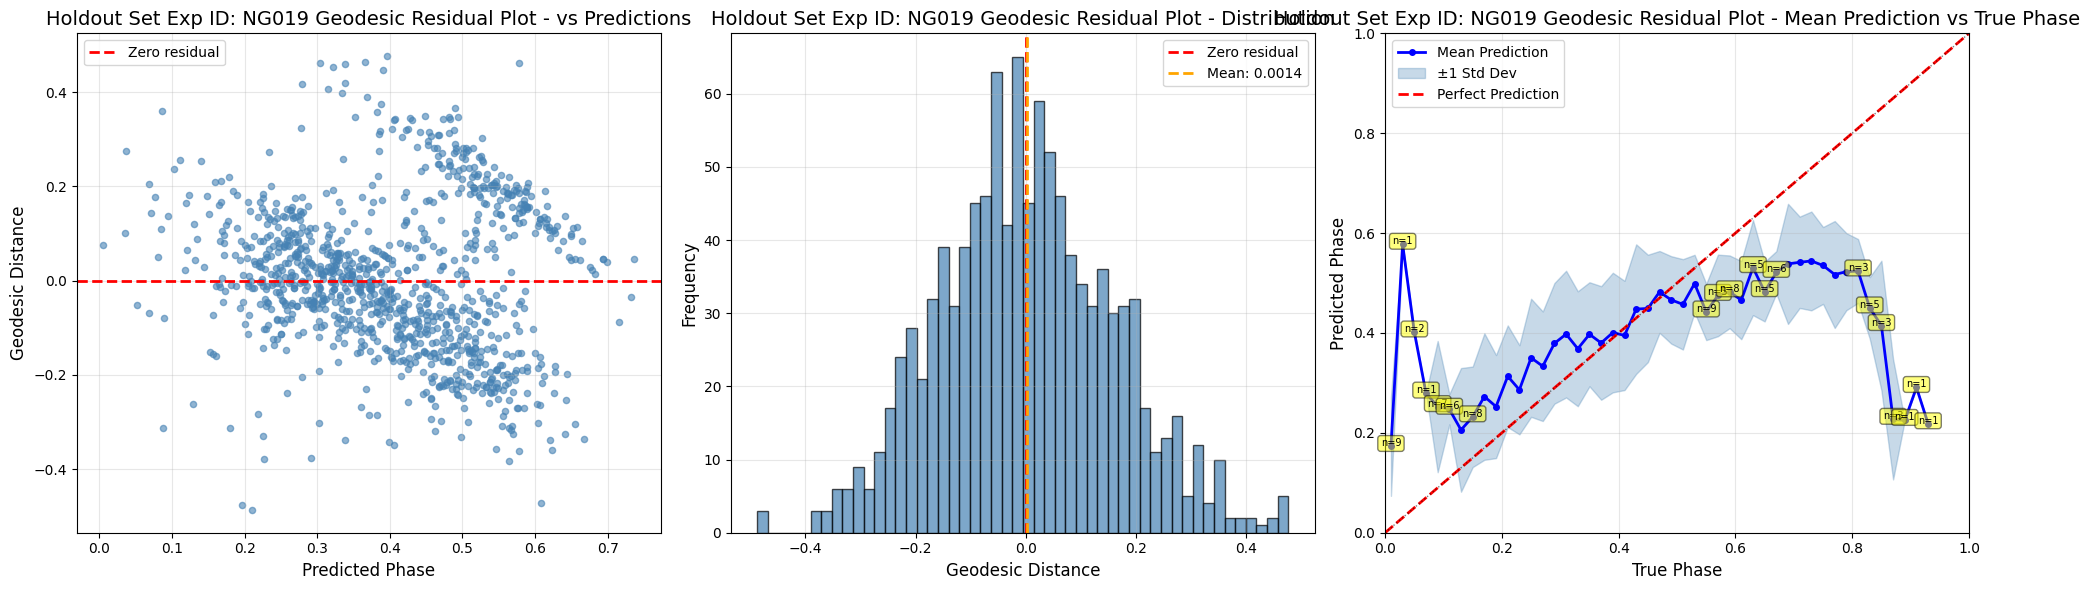

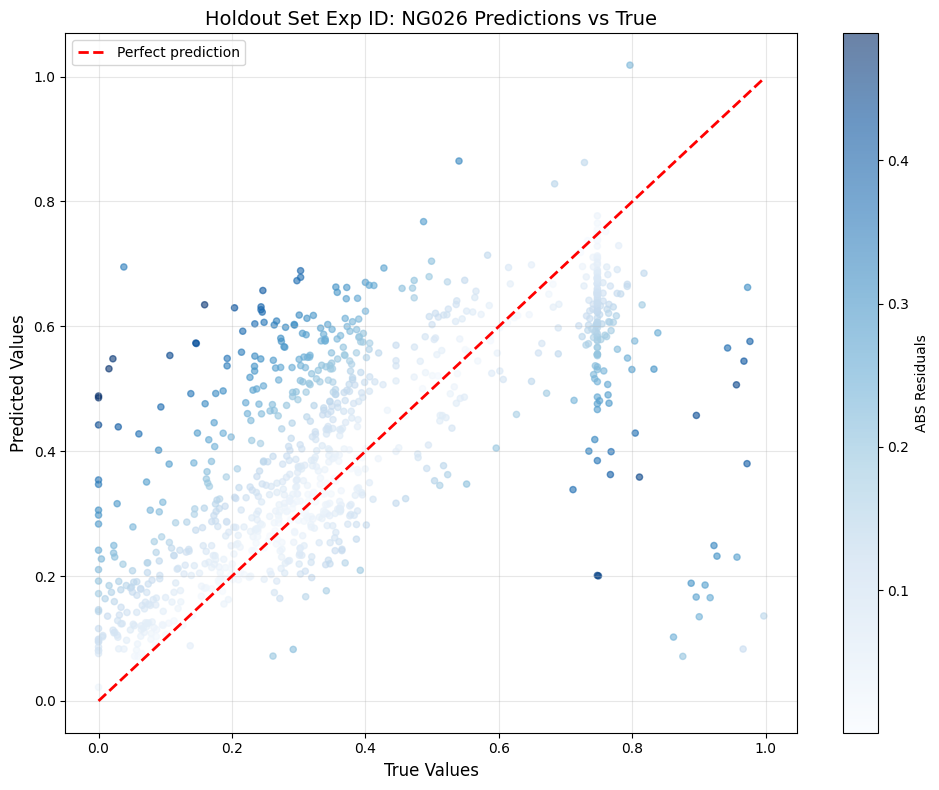

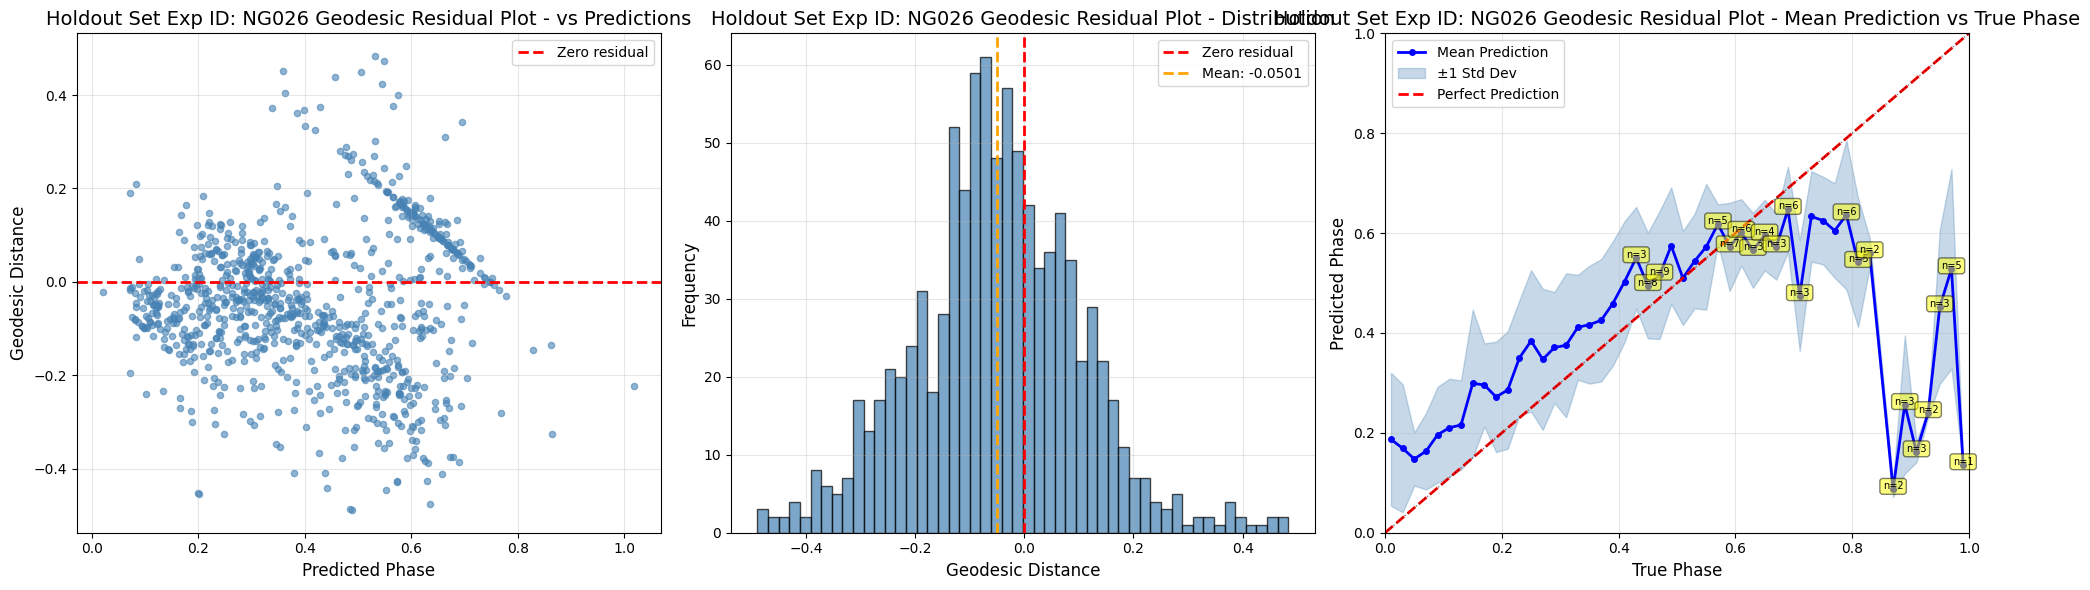

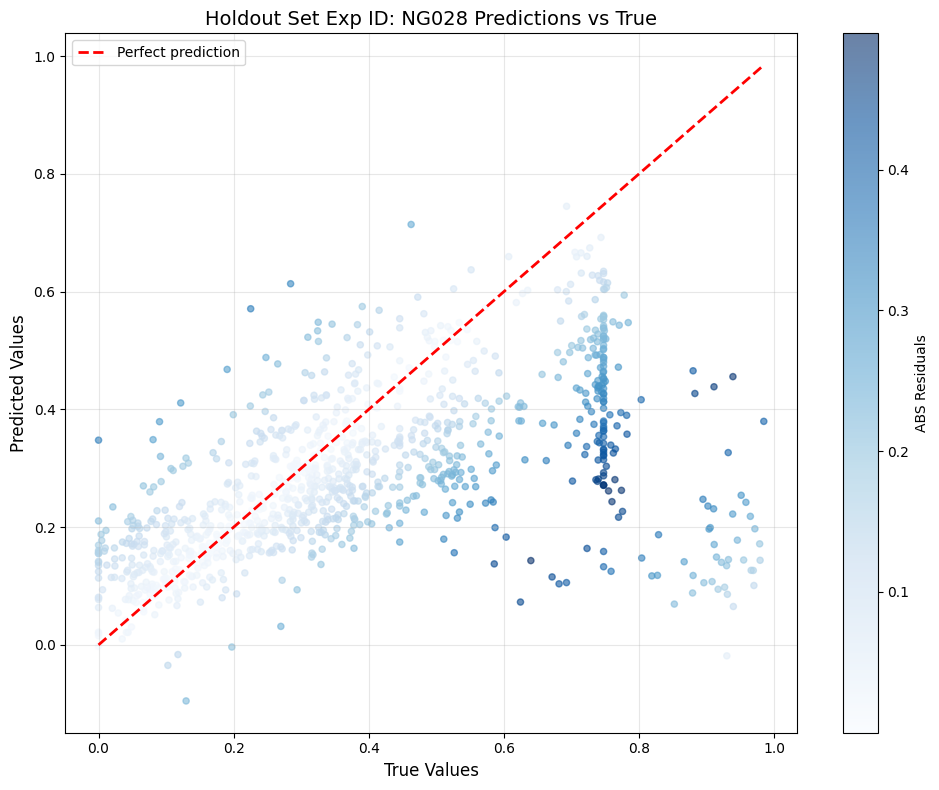

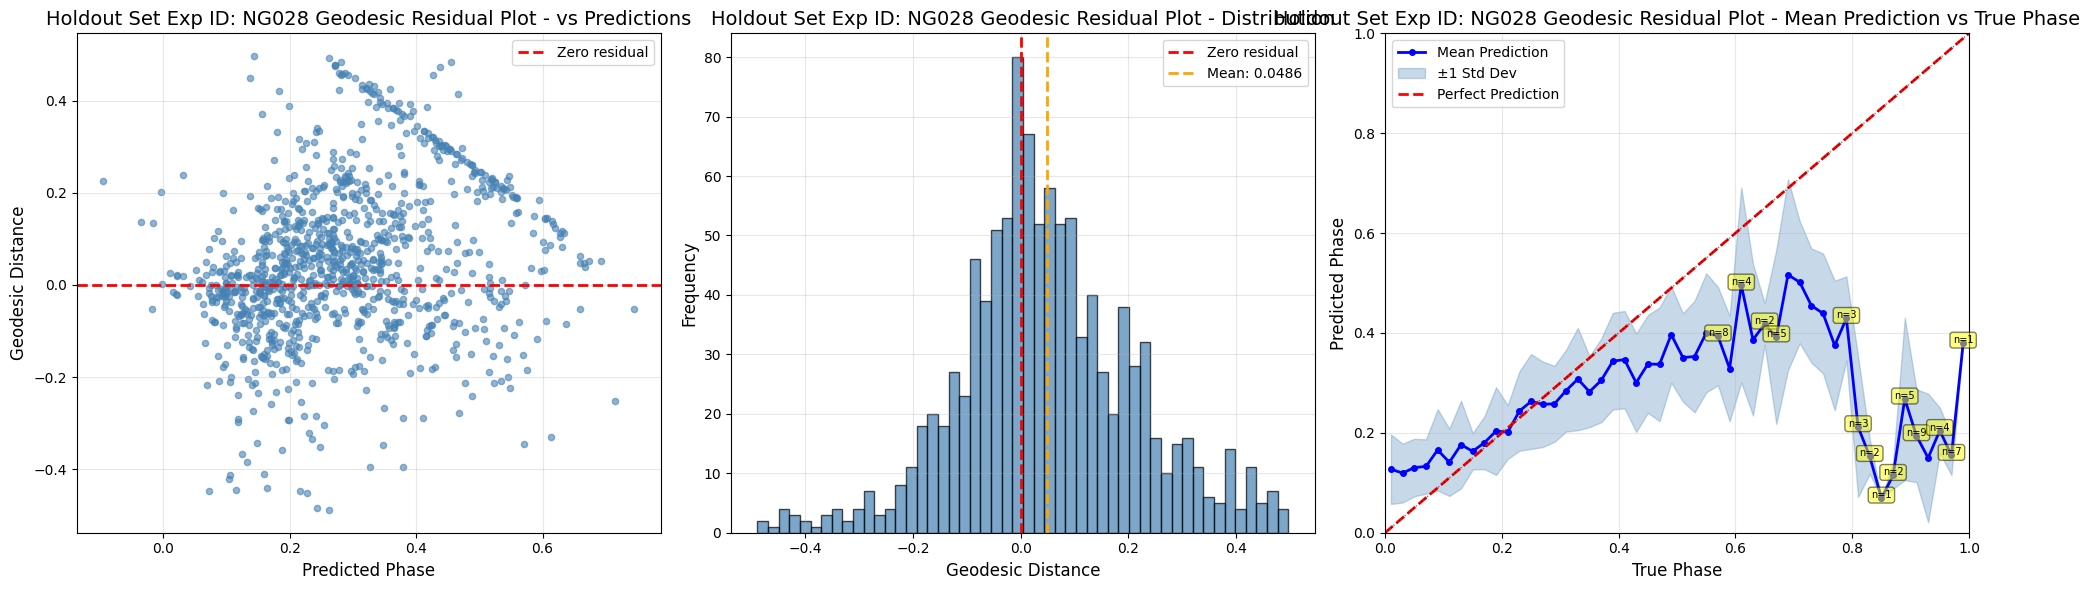

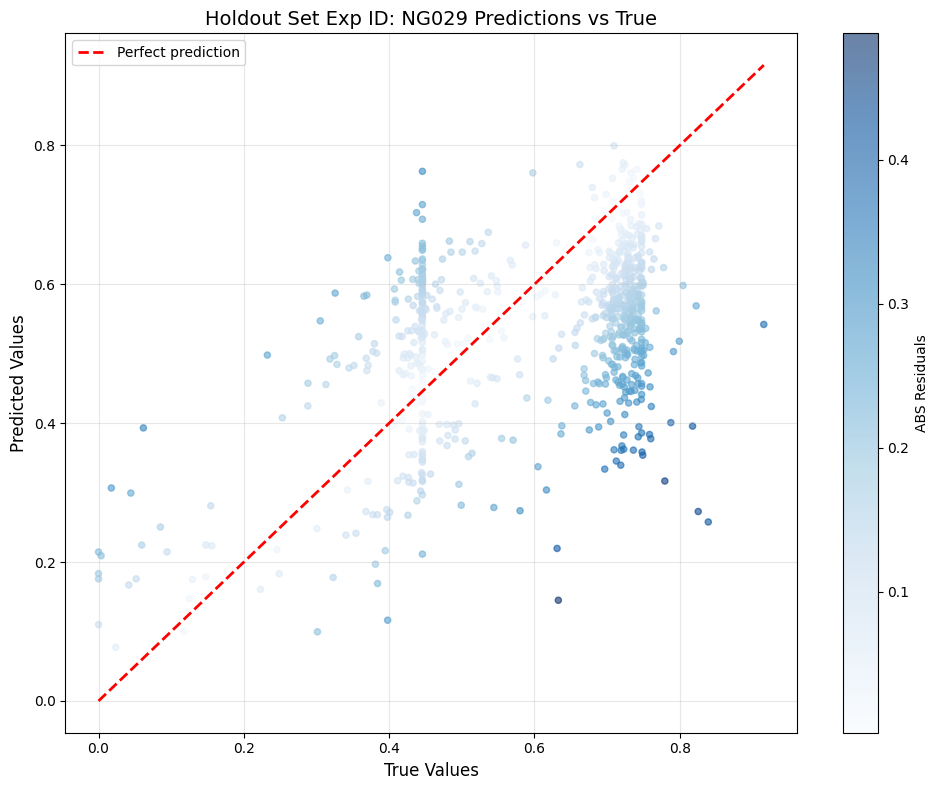

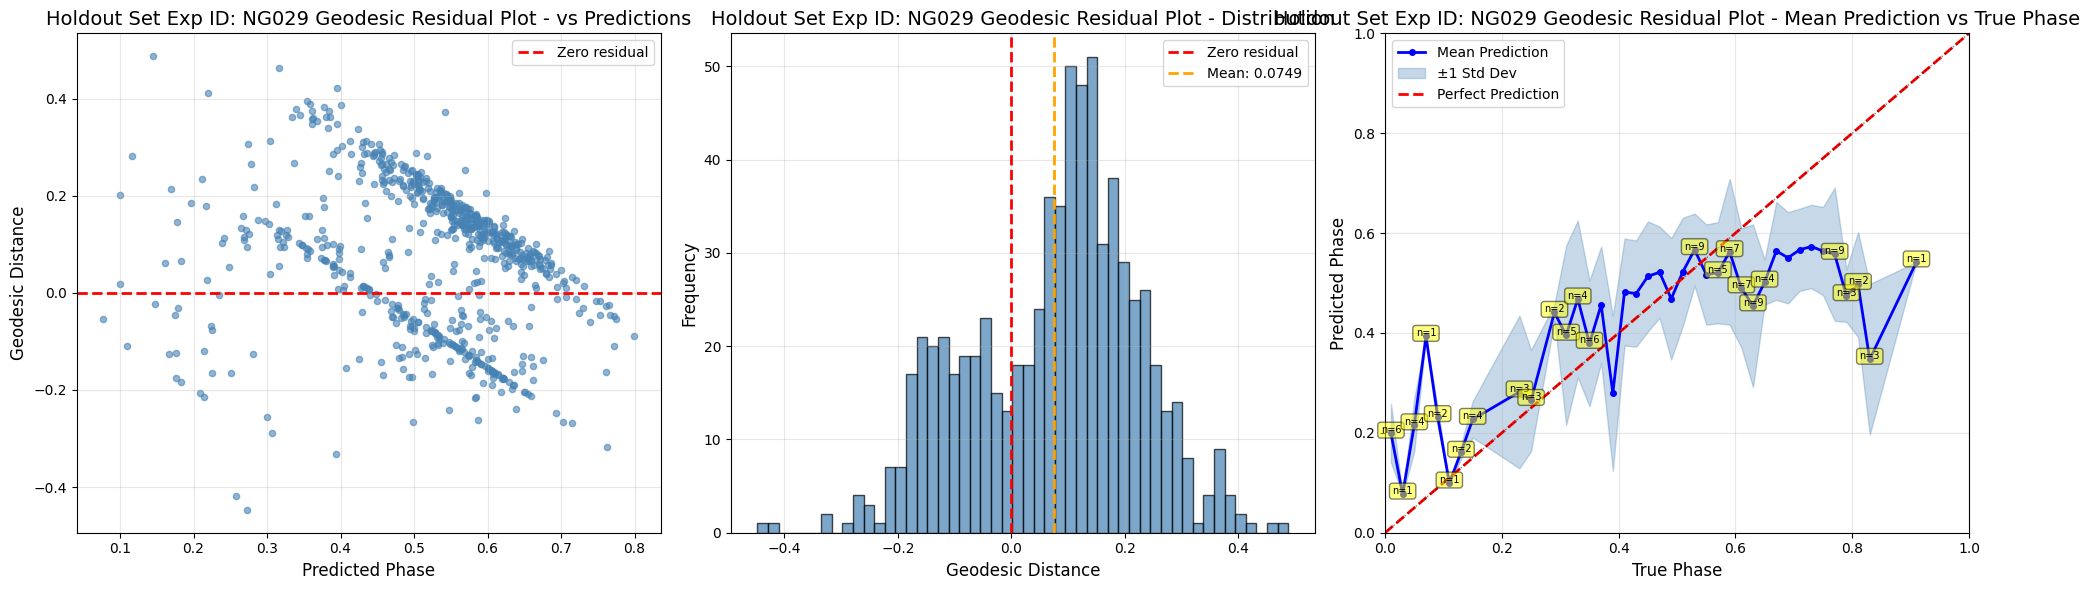

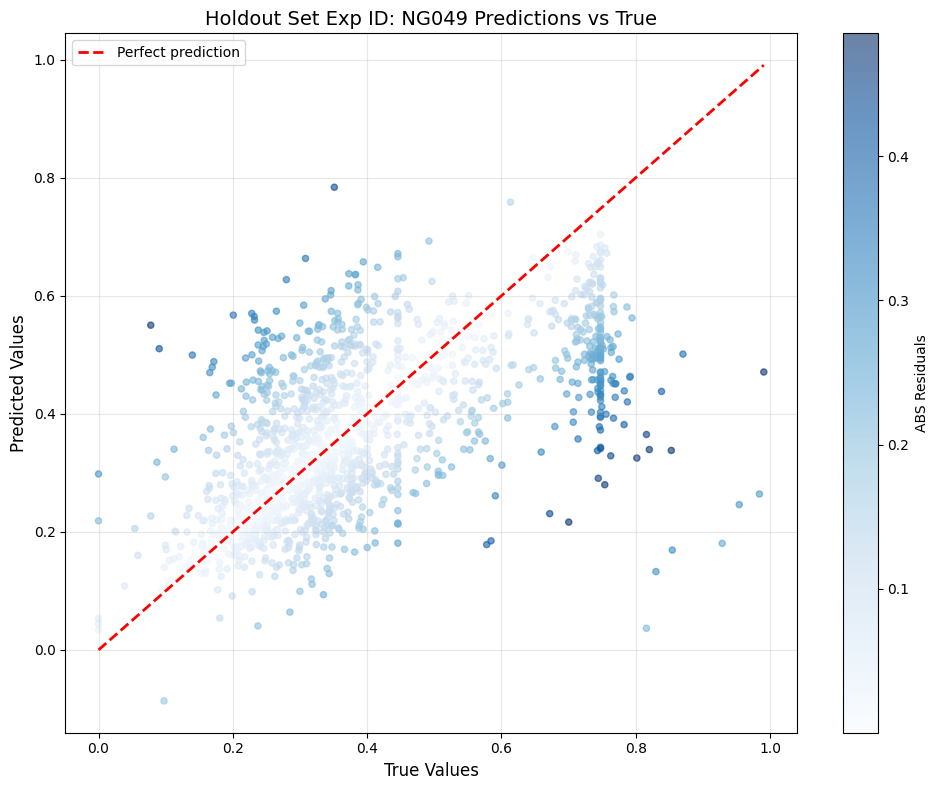

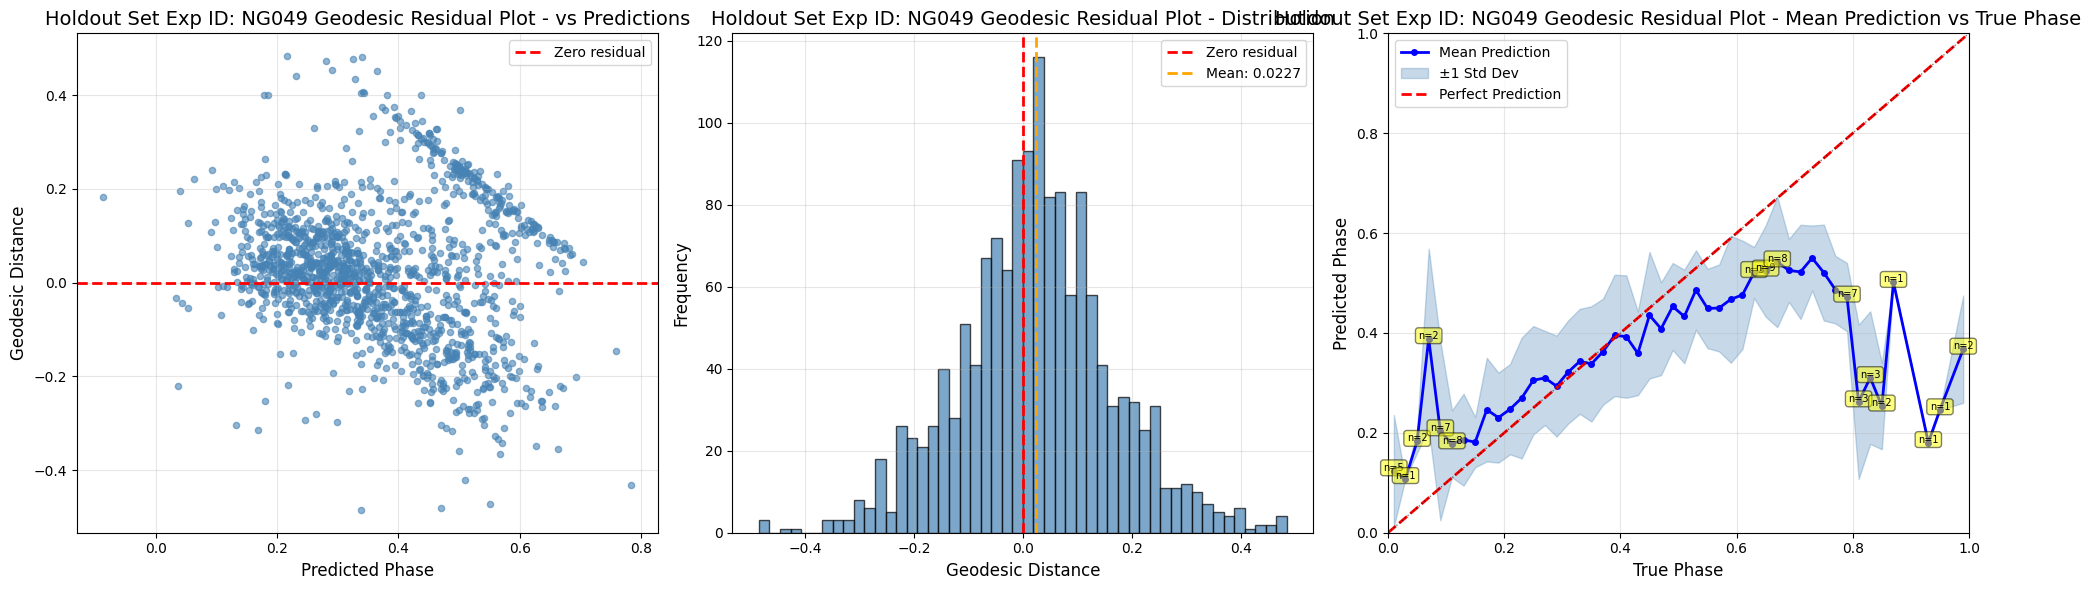

In [7]:
# Create evaluator
eval_config = EvaluationConfig(
    is_phase=True,  # Set to True if predicting phase (1D projection)
    plots_to_generate=["scatter", "geodesic_residual"]
)

evaluator = Evaluator(config=eval_config, projector=projector)
exp_id_evaluation_results = {}
for exp_id, (y_pred, y_true) in exp_id_evaluation_preds.items():
    print(f"\nEvaluating exp_id: {exp_id}")
    # Run evaluation
    result = evaluator.evaluate(
        y_true=y_true.squeeze(),
        y_pred=y_pred.squeeze(),
        prefix=f"Holdout Set Exp ID: {exp_id}"
    )

    # Print metrics
    print("\n" + "=" * 60)
    print(f"EVALUATION RESULTS - Holdout exp_id: {HOLDOUT_EXP_ID}")
    print("=" * 60)
    exp_id_evaluation_results[exp_id] = result.metrics.to_dict(prefix="test")

print("\n" + "=" * 60)
print(f"SUMMARY OF EVALUATION RESULTS FOR ALL EXP_IDS")
print("=" * 60)
for exp_id, metrics in exp_id_evaluation_results.items():
    print(f"\nResults for exp_id: {exp_id}")
    print("-" * 40)
    print(f"Metrics:")
    for key, value in metrics.items():
        if value is None:
            continue
        print(f"  {key}: {value}")
    

## Summary

In [ ]:
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Holdout Experiment ID: {HOLDOUT_EXP_ID}")
print(f"Model Folder: {newest_holdout_folder.name}")
print(f"Checkpoint: {best_ckpt_path.name}")
print(f"Checkpoint Subfolder: {best_ckpt_path.parent.relative_to(newest_holdout_folder)}")
print(f"Number of test samples: {len(y_true)}")
print(f"\nKey Metrics:")
for key, value in metrics_dict.items():
    print(f"  {key}: {value:.4f}")

### Random holdout evaluation

In [3]:
# model trained on all focal planes
ckpt_path = "/myhome/iris/lightning_logs/cnet_experiment_polygon_projection-20251120-152638/cnet_cell_cycle/ngbsivhn/checkpoints/epoch140-val_loss6.0552.ckpt"

# model trained on middle focal plane
ckpt_path = "/myhome/iris/lightning_logs/full_dataset-20251217-212156/cell-cycle-loeo/4erwbzxy/checkpoints/epoch99-val_loss0.0214.ckpt"

model, loader, projector = load_ckpt_artifacts(ckpt_path, split="test")
device = get_device()
model = model.to(device)

Loading checkpoint from: /myhome/iris/lightning_logs/full_dataset-20251217-212156/cell-cycle-loeo/4erwbzxy/checkpoints/epoch99-val_loss0.0214.ckpt

Setting up ModularCellDataModule

Creating feature transform pipeline
   - Using [{'class_path': 'sklearn.preprocessing.StandardScaler', 'init_args': {}}] transforms

Creating image transform pipeline
   - Using [] transforms

Creating data source from: /myhome/iris/data/fucci_3t3_221124_filtered_noNG030JP208_with_nuclei_seg.h5
   ✓ Found 22,677 total cells

Applying quality filters:
   - Plane count: 3
   - Max objects: 1
   - Min segmentation pixels: 10
   - Max nuclei outside ratio: 0.2
✓ Loaded filter results from cache: /myhome/iris/data/fucci_3t3_221124_filtered_noNG030JP208_with_nuclei_seg_filtered_23c07912.json

FILTERING STATISTICS
Total cells:                22,677
Valid cells:                16,759
Invalid cells:              5,918

Rejection reasons:
  - nuclei_too_large              : 2,540
  - exp_id_excluded               : 1

/opt/conda/envs/iris_env/lib/python3.10/site-packages/torch/cuda/__init__.py:827: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Evaluating holdout set: 100%|██████████| 27/27 [03:13<00:00,  7.17s/it]


Predictions shape: (1675, 1)
Labels shape: (1675, 1)

EVALUATION RESULTS - Random holdout set
test/geodesic_mae: 0.10904247313737869
test/geodesic_mse: 0.02102651260793209
test/geodesic_rmse: 0.1450052157956123
test/geodesic_r2: 0.5617930889129639


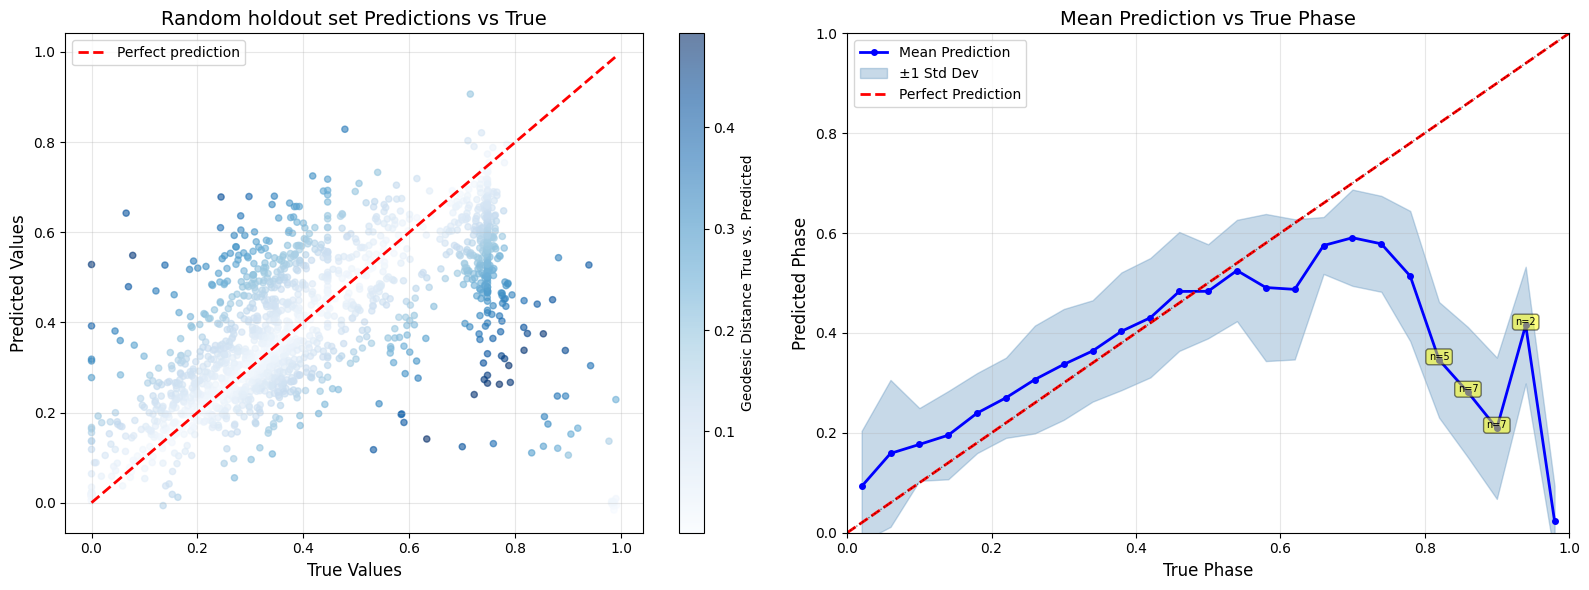

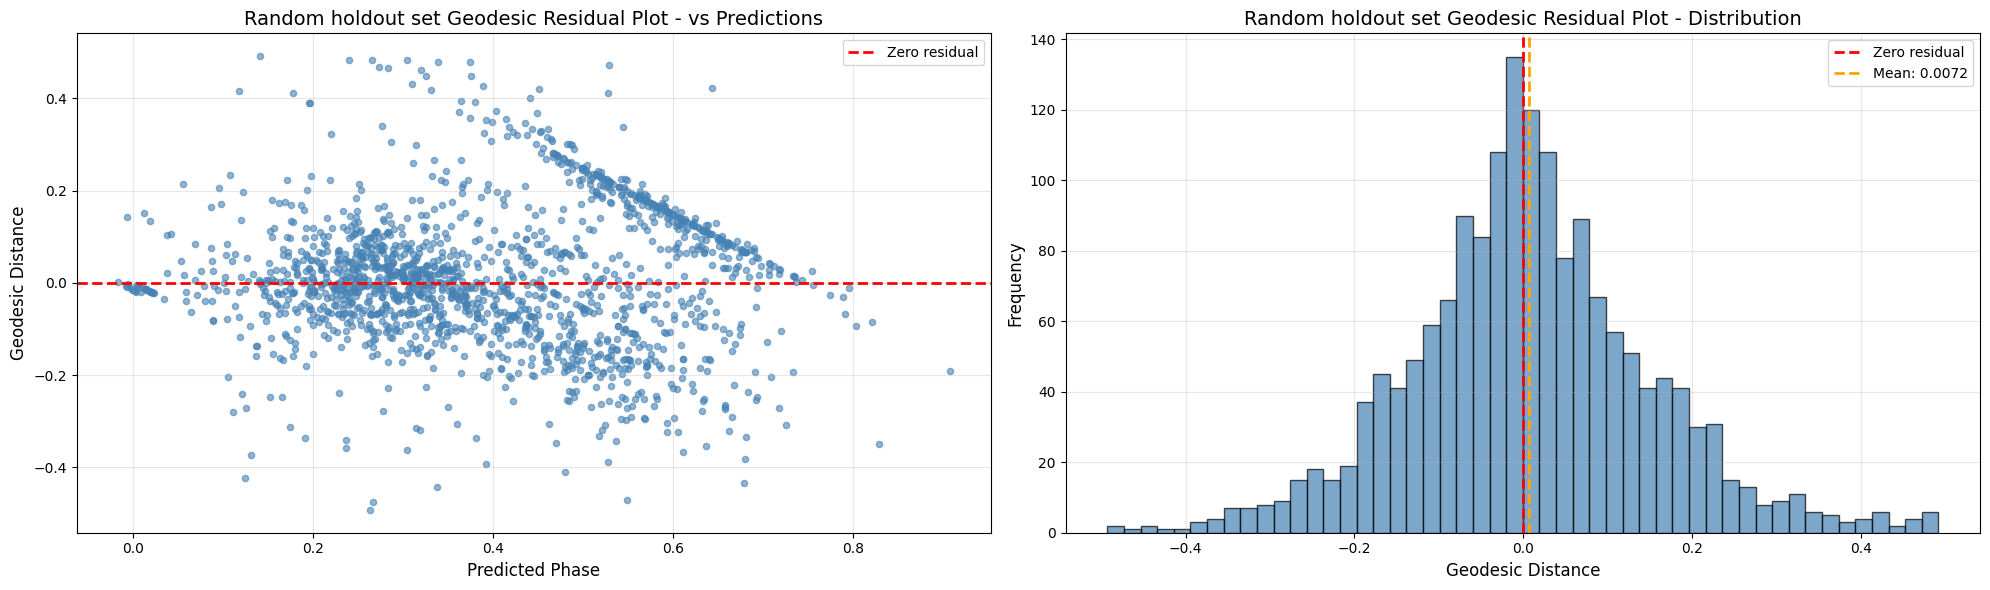

In [4]:
from tqdm import tqdm

model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for batch in tqdm(loader, desc="Evaluating holdout set"):
        (images, features), labels = batch
        images = images.to(device)
        features = features.to(device)
        preds = model(images, features)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.numpy())

y_pred = np.concatenate(all_preds, axis=0)
y_true = np.concatenate(all_labels, axis=0)
print(f"Predictions shape: {y_pred.shape}")
print(f"Labels shape: {y_true.shape}")

eval_config = EvaluationConfig(
    is_phase=True,  # Set to True if predicting phase (1D projection)
    plots_to_generate=["scatter", "geodesic_residual"]
)
evaluator = Evaluator(config=eval_config, projector=projector)
result = evaluator.evaluate(
    y_true=y_true.squeeze(),
    y_pred=y_pred.squeeze(),
    prefix="Random holdout set"
)

print("\n" + "=" * 60)
print(f"EVALUATION RESULTS - Random holdout set")
print("=" * 60)
metrics_dict = result.metrics.to_dict(prefix="test")
for key, value in metrics_dict.items():
    if value is None:
        continue
    print(f"{key}: {value}")